<a href="https://colab.research.google.com/github/HappyRF/Smart-Parking-Occupancy-Analytics-Dashboard/blob/main/Smart_Parking_Occupancy_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Smart Parking Occupancy Analytics
*Project Description*
- The Smart Parking Occupancy Analytics project analyzes parking usage across different zones, time slots, and days to identify occupancy trends, peak hours, and space utilization. The insights help optimize parking allocation, reduce congestion, improve operational efficiency, and support data-driven parking management decisions.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/HappyRF/Smart-Parking-Occupancy-Analytics-Dashboard/refs/heads/main/Smart_Parking_Occupancy_Dataset.csv")
df

,Date,Day,Time Slot,Parking Zone,Total Parking Spaces,Occupied Spaces,Available Spaces,Vehicle Type,Average Parking Duration (hrs)
0,2026-01-01,Thursday,08:00-10:00,A,120,91,29,Visitor,2.6
1,2026-01-01,Thursday,10:00-12:00,A,120,101,19,Bike,2.7
2,2026-01-01,Thursday,12:00-14:00,A,120,100,20,Visitor,1.3
3,2026-01-01,Thursday,14:00-16:00,A,120,80,40,Visitor,4.0
4,2026-01-01,Thursday,16:00-18:00,A,120,120,0,Visitor,1.1
...,...,...,...,...,...,...,...,...,...
1195,2026-03-01,Sunday,08:00-10:00,D,60,43,17,Visitor,1.6
1196,2026-03-01,Sunday,10:00-12:00,D,60,47,13,Bike,2.7
1197,2026-03-01,Sunday,12:00-14:00,D,60,51,9,EV,1.0
1198,2026-03-01,Sunday,14:00-16:00,D,60,50,10,Car,2.9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            1200 non-null   object 
 1   Day                             1200 non-null   object 
 2   Time Slot                       1200 non-null   object 
 3   Parking Zone                    1200 non-null   object 
 4   Total Parking Spaces            1200 non-null   int64  
 5   Occupied Spaces                 1200 non-null   int64  
 6   Available Spaces                1200 non-null   int64  
 7   Vehicle Type                    1200 non-null   object 
 8   Average Parking Duration (hrs)  1200 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 84.5+ KB


In [6]:
df.describe()

,Total Parking Spaces,Occupied Spaces,Available Spaces,Average Parking Duration (hrs)
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,90.000000,73.731667,16.268333,2.437000
std,22.370003,20.963561,10.492684,0.885759
min,60.000000,34.000000,0.000000,1.000000
25%,75.000000,57.000000,8.000000,1.700000
50%,90.000000,73.000000,16.000000,2.400000
75%,105.000000,89.000000,24.000000,3.200000
max,120.000000,120.000000,44.000000,4.000000


In [7]:
df.columns

Index(['Date', 'Day', 'Time Slot', 'Parking Zone', 'Total Parking Spaces',
       'Occupied Spaces', 'Available Spaces', 'Vehicle Type',
       'Average Parking Duration (hrs)'],
      dtype='object')

## Questions to Answer
1. Which parking zone is occupied the most?

In [8]:
occupied_zone = df.groupby('Parking Zone')['Occupied Spaces'].sum().sort_values(ascending = False)
highest_occupied_zone = occupied_zone.idxmax()
highest_occupied_space = occupied_zone.max()
occupied_zone

,Occupied Spaces
Parking Zone,
A,29633
B,24521
C,19649
D,14675


In [9]:
f"The zone with the most occupied space is zone {highest_occupied_zone} with a total occupied space of {highest_occupied_space}"

'The zone with the most occupied space is zone A with a total occupied space of 29633'

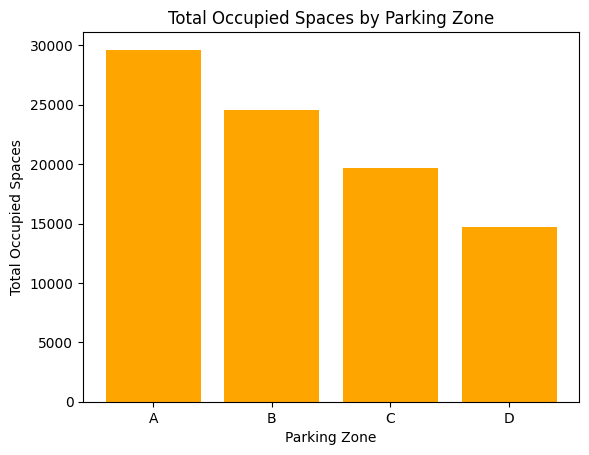

In [10]:
plt.bar(
    occupied_zone.index,
    occupied_zone.values,
    color = "orange"
)
plt.title("Total Occupied Spaces by Parking Zone")
plt.xlabel("Parking Zone")
plt.ylabel("Total Occupied Spaces")
plt.show()

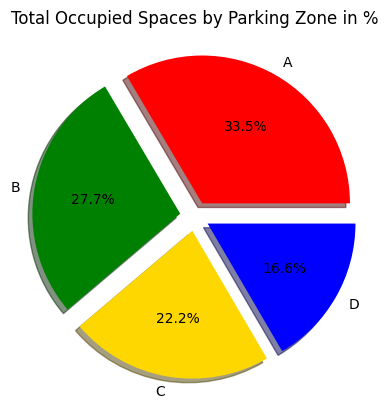

In [11]:
colors=['red','green','gold','blue']
explode=(0.1,0.1,0.1,0.1)
plt.pie(
    occupied_zone.values,
    labels=occupied_zone.index,
    autopct='%1.1f%%',
    explode = explode,
    colors = colors,
    shadow = True
)
plt.title("Total Occupied Spaces by Parking Zone in %")
plt.show()

2. At what time is parking busiest?

In [12]:
time_occupancy = df.groupby('Time Slot')["Occupied Spaces"].sum().sort_values(ascending=False)
busiest_time = time_occupancy.idxmax()
occupied_space = time_occupancy.max()
time_occupancy

,Occupied Spaces
Time Slot,
16:00-18:00,20536
10:00-12:00,19349
12:00-14:00,17230
08:00-10:00,16257
14:00-16:00,15106


In [13]:
f"The busiest parking time is {busiest_time} with {occupied_space} occupied spaces."

'The busiest parking time is 16:00-18:00 with 20536 occupied spaces.'

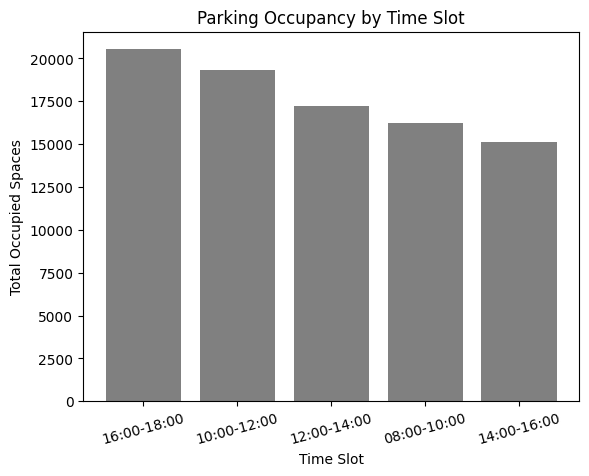

In [14]:
plt.bar(
    time_occupancy.index,
    time_occupancy.values,
    color = 'grey'
)
plt.title("Parking Occupancy by Time Slot")
plt.xlabel("Time Slot")
plt.ylabel("Total Occupied Spaces")
plt.xticks(rotation=15)
plt.show()

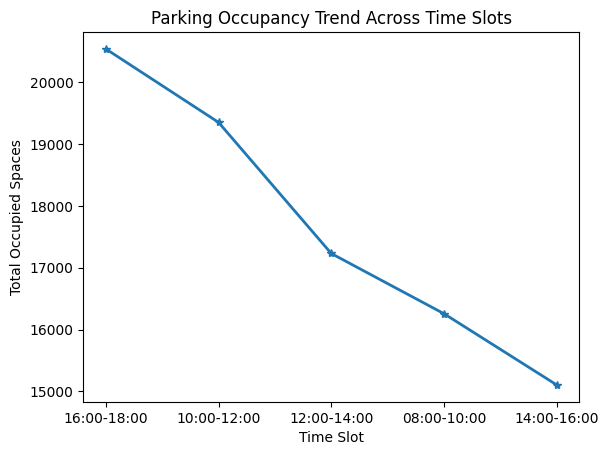

In [16]:
plt.plot(
    time_occupancy.index,
    time_occupancy.values,
    marker='*',
    linewidth = 2
)
plt.title("Parking Occupancy Trend Across Time Slots")
plt.xlabel("Time Slot")
plt.ylabel("Total Occupied Spaces")
plt.show()

3.  Which vehicle type occupies more parking spaces?

In [17]:
vehicle_occupancy = df.groupby('Vehicle Type')['Occupied Spaces'].sum().sort_values(ascending = False)
common_vehicle = vehicle_occupancy.idxmax()
occupied_number = vehicle_occupancy.max()
vehicle_occupancy

,Occupied Spaces
Vehicle Type,
Bike,23428
Car,22936
Visitor,21437
EV,20677


In [18]:
f"The vehicle type occupying the most parking spaces is {common_vehicle} with {occupied_number} occupied spaces."

'The vehicle type occupying the most parking spaces is Bike with 23428 occupied spaces.'

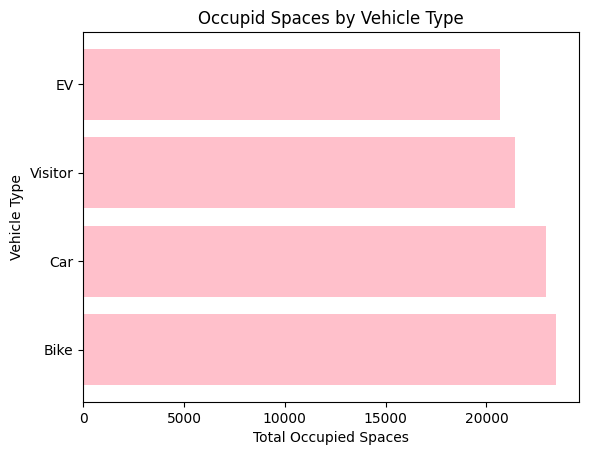

In [19]:
plt.barh(
    vehicle_occupancy.index,
    vehicle_occupancy.values,
    color = "pink"
)
plt.title("Occupid Spaces by Vehicle Type")
plt.xlabel("Total Occupied Spaces")
plt.ylabel("Vehicle Type")
plt.show()

4. What is the average parking duration?

In [20]:
average_duration = df["Average Parking Duration (hrs)"].mean()

f"Average Parking Duration: {average_duration:.2f} hours"

'Average Parking Duration: 2.44 hours'

5. How can parking congestion be reduced?

- Overall Parking Occupancy Rate

In [23]:
occupancy_rate = (df['Occupied Spaces'].sum() / df['Total Parking Spaces'].sum())*100
f"Overall Parking Occupancy Rate {occupancy_rate:.2f}%"

'Overall Parking Occupancy Rate 81.92%'

- Occupancy Rate by Parking Zone

In [26]:
zone_rate = (
    df.groupby('Parking Zone')['Occupied Spaces'].sum() /
    df.groupby('Parking Zone')['Total Parking Spaces'].sum()
)*100

zone_rate = zone_rate.sort_values(ascending = False)
zone_rate

,0
Parking Zone,
A,82.313889
C,81.870833
B,81.736667
D,81.527778


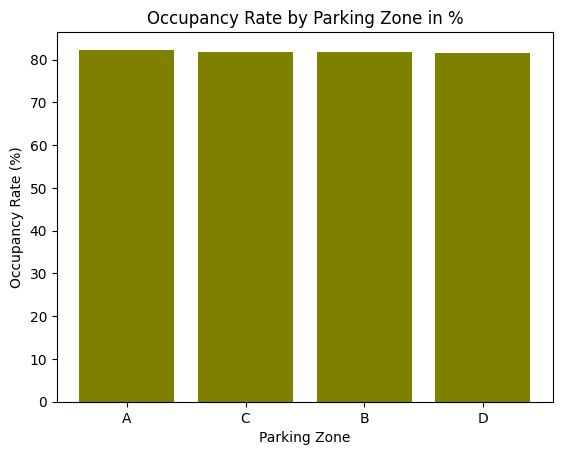

In [31]:
plt.bar(
    zone_rate.index,
    zone_rate.values,
    color = 'olive'
)
plt.title("Occupancy Rate by Parking Zone in %")
plt.xlabel('Parking Zone')
plt.ylabel('Occupancy Rate (%)')
plt.show()

- Occupancy Rate by Time Slot

In [28]:
time_rate = (
    df.groupby('Time Slot')['Occupied Spaces'].sum() /
    df.groupby('Time Slot')['Total Parking Spaces'].sum()
)*100

time_rate = time_rate.sort_values(ascending = False)
time_rate

,0
Time Slot,
16:00-18:00,95.074074
10:00-12:00,89.578704
12:00-14:00,79.768519
08:00-10:00,75.263889
14:00-16:00,69.935185


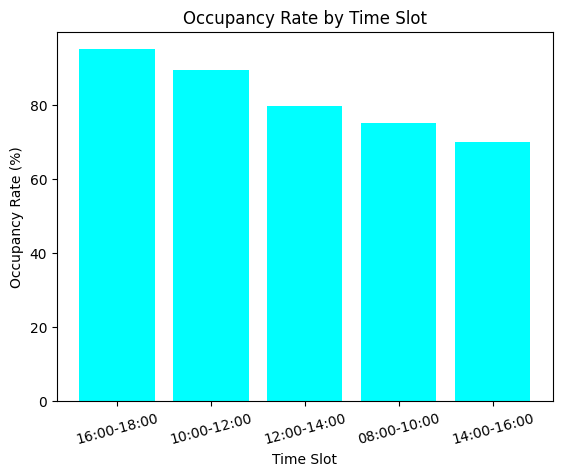

In [29]:
plt.bar(
    time_rate.index,
    time_rate.values,
    color = 'cyan'
)
plt.title("Occupancy Rate by Time Slot")
plt.xlabel("Time Slot")
plt.xticks(rotation = 15)
plt.ylabel("Occupancy Rate (%)")
plt.show()

#### To reduce parking congestion, the following recommendations can be implemented:
- Assign more parking spaces to areas that consistently experience high occupancy.
- Encourage users to use less congested parking zones by providing clear signs and guidance systems.
- Implement smart parking guidance systems to direct drivers to available parking spaces in real time.
- Implement time limits in high-demand areas to reduce parking congestion.
- Monitor occupancy continuously using parking sensors and dashboards.